# Adaptive Smart Lighting Control — Environment Exploration
This notebook explores the SmartLightingEnv custom Gymnasium environment to understand its dynamics before model training.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from env.lighting_env import SmartLightingEnv

In [10]:
env = SmartLightingEnv()

obs, _ = env.reset(seed=0)

time_list = []
daylight_list = []
occupancy_list = []
target_list = []
reward_list = []

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()  # random exploration
    obs, reward, terminated, truncated, info = env.step(action)

    time_list.append(info["time_of_day"])
    daylight_list.append(info["daylight_intensity"])
    occupancy_list.append(info["occupancy_status"])
    target_list.append(info["target_illuminance"])
    reward_list.append(reward)

env.close()

## Section 2 — Environment Dynamics Over 24 Hours

Simulate one full day to visualise the natural patterns of daylight, occupancy, target illuminance, and target colour temperature.

# Daylight Pattern

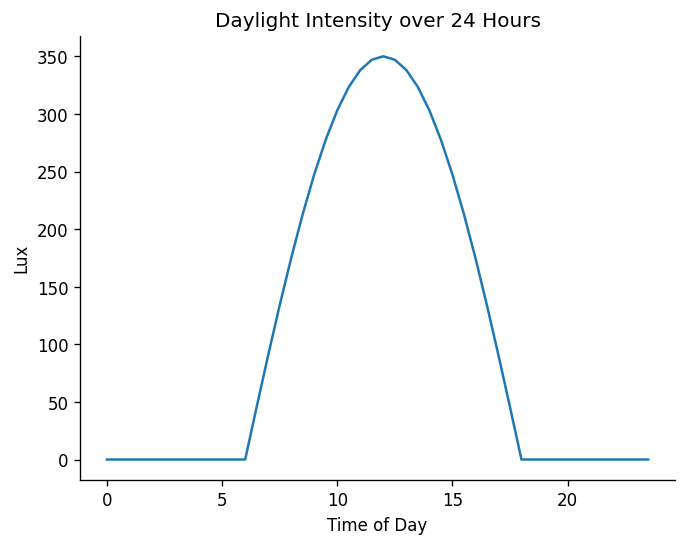

In [11]:
plt.figure()
plt.plot(time_list, daylight_list)
plt.title("Daylight Intensity over 24 Hours")
plt.xlabel("Time of Day")
plt.ylabel("Lux")
plt.grid()
plt.show()

## Occupancy Pattern

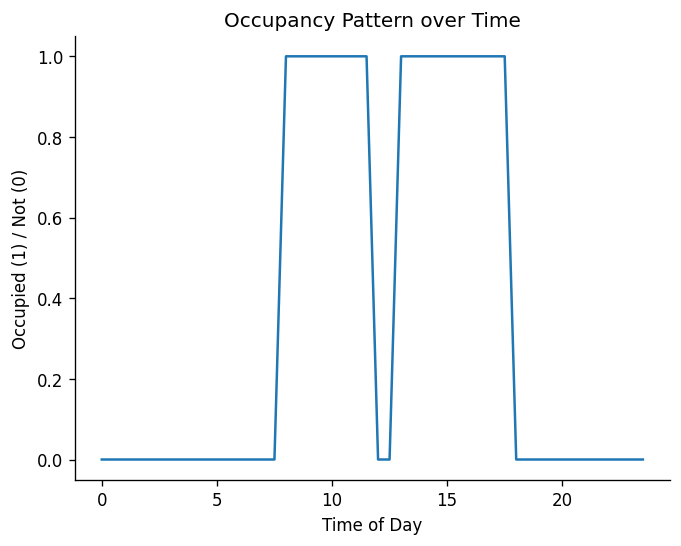

In [12]:
plt.figure()
plt.plot(time_list, occupancy_list)
plt.title("Occupancy Pattern over Time")
plt.xlabel("Time of Day")
plt.ylabel("Occupied (1) / Not (0)")
plt.grid()
plt.show()

## Target Illuminance

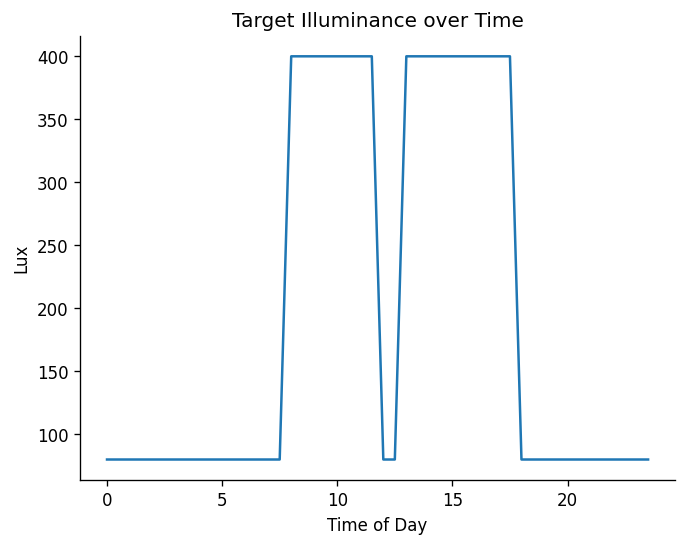

In [14]:
plt.figure()
plt.plot(time_list, target_list)
plt.title("Target Illuminance over Time")
plt.xlabel("Time of Day")
plt.ylabel("Lux")
plt.grid()
plt.show()

## Reward Distribution

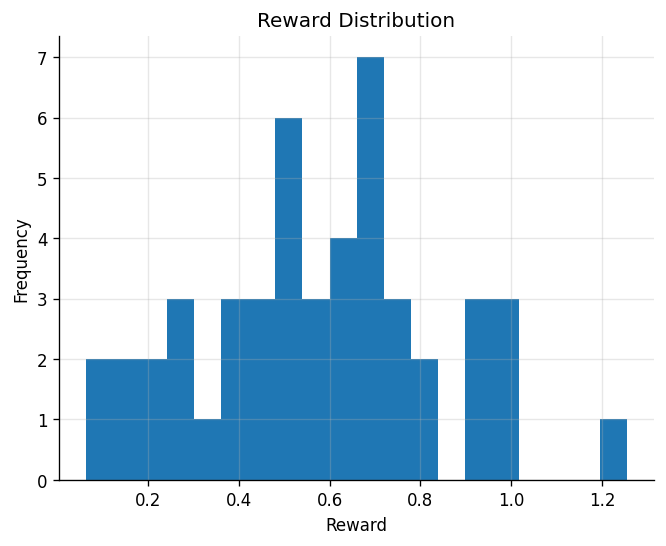

In [15]:
plt.figure()
plt.hist(reward_list, bins=20)
plt.title("Reward Distribution")
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.show()

## Error Analysis

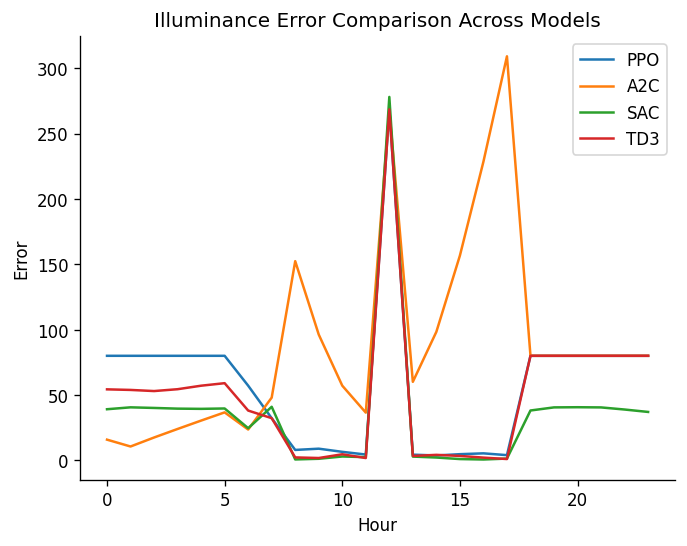

In [17]:
from stable_baselines3 import PPO, A2C, SAC, TD3

models = {
    "PPO": PPO.load("results_train/ppo/run_1/best_model/best_model.zip"),
    "A2C": A2C.load("results_train/a2c/run_1/best_model/best_model.zip"),
    "SAC": SAC.load("results_train/sac/run_1/best_model/best_model.zip"),
    "TD3": TD3.load("results_train/td3/run_1/best_model/best_model.zip"),
}

results = {}

for name, model in models.items():
    env = SmartLightingEnv()
    obs, _ = env.reset(seed=0)

    error_by_hour = {}
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        hour = int(info["time_of_day"])
        error = info["illuminance_error"]

        if hour not in error_by_hour:
            error_by_hour[hour] = []

        error_by_hour[hour].append(error)

    env.close()

    hours = sorted(error_by_hour.keys())
    avg_error = [np.mean(error_by_hour[h]) for h in hours]

    results[name] = (hours, avg_error)

# 📊 Plot ALL models
plt.figure()

for name, (hours, avg_error) in results.items():
    plt.plot(hours, avg_error, label=name)

plt.title("Illuminance Error Comparison Across Models")
plt.xlabel("Hour")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

## Environment Dynamics Analysis

The environment follows a 24-hour cycle where daylight intensity gradually increases in the morning, peaks at midday, and decreases towards the evening. Occupancy is active during working hours (8:00–12:00 and 13:00–18:00), and inactive during other periods. This creates varying lighting requirements across time.

## Error and Inefficiency Analysis
The results show that the model performs well during stable daylight conditions but experiences higher errors during transition periods such as early morning and evening. These periods require rapid adjustments in LED brightness due to changing natural light.

Additionally, during unoccupied periods, some unnecessary lighting is observed, indicating inefficiencies in energy usage. This suggests that further optimization can improve energy-saving performance.

## Model Comparison Analysis 

The comparison shows that different models perform differently across time periods. PPO demonstrates stable performance with lower error across most hours. SAC shows better energy efficiency but slightly higher error during transition periods. TD3 exhibits more fluctuation due to exploration noise, while A2C shows moderate performance.

All models experience higher errors during early morning and evening, where daylight changes rapidly, indicating these are the most challenging periods for control.

## Reward Comparison

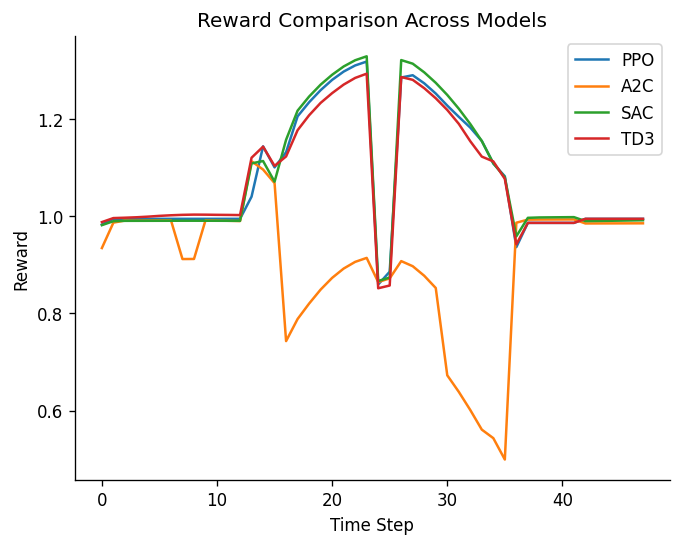

In [18]:
reward_results = {}

for name, model in models.items():
    env = SmartLightingEnv()
    obs, _ = env.reset(seed=0)

    rewards = []
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)

    env.close()
    reward_results[name] = rewards

# Plot reward
plt.figure()

for name, rewards in reward_results.items():
    plt.plot(rewards, label=name)

plt.title("Reward Comparison Across Models")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.show()

## Average Score Table

In [19]:
for name, model in models.items():
    env = SmartLightingEnv()
    obs, _ = env.reset(seed=0)

    overall_scores = []
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        overall_scores.append(info["overall_score"])

    env.close()

    print(f"{name} Average Overall Score: {np.mean(overall_scores):.2f}")

PPO Average Overall Score: 86.61
A2C Average Overall Score: 64.50
SAC Average Overall Score: 84.61
TD3 Average Overall Score: 84.98


The results show that performance varies across time, with higher errors during early morning and evening due to rapid daylight changes.

Among the models, PPO demonstrates the most stable performance, while SAC shows better energy efficiency. TD3 exhibits higher variability due to exploration noise, and A2C performs moderately.

This indicates that PPO provides the best balance between stability and performance in this environment.

## Note on Exploration Results

The results presented in this notebook are based on single-episode simulations and are used for analyzing environment dynamics and model behavior. These results do not represent the final performance of the models, which is evaluated separately using multiple episodes and statistical averaging.